In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from tqdm import tqdm
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import seaborn as sns

In [2]:
states = np.load("Data/states/raw_states.npy")

100%|██████████| 300/300 [12:20:29<00:00, 148.10s/it]  


Miglior k secondo Silhouette: 874
Miglior k secondo AIC (euristico): 602
Miglior k secondo BIC (euristico): 600


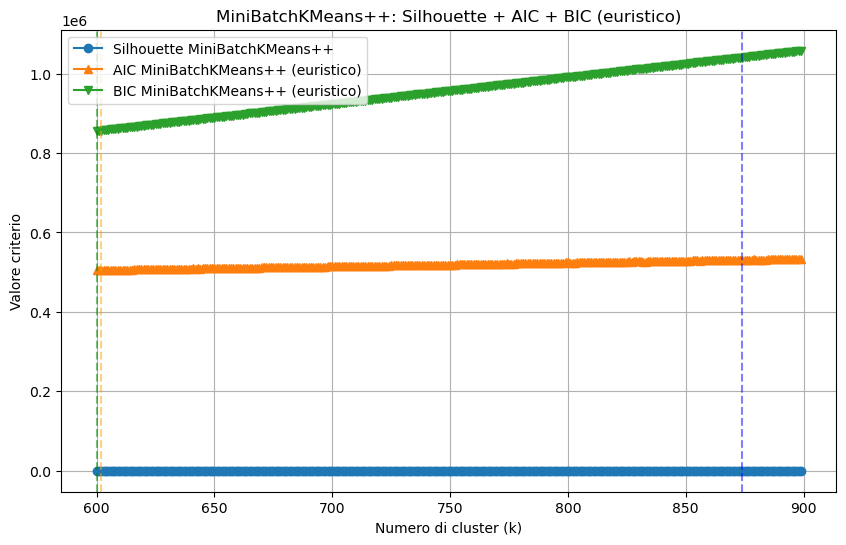

In [ ]:
n_samples, n_features = states.shape

# =========================
# 2. Test diversi k per MiniBatchKMeans++
# =========================
k_values = range(600,900)

sil_scores = []
aic_scores = []
bic_scores = []

for k in tqdm(k_values):
    mbk = MiniBatchKMeans(
        n_clusters=k,
        init="k-means++",
        batch_size=2048,
        max_iter=200,
        random_state=42
    )
    labels = mbk.fit_predict(states)
    
    # Silhouette
    sil = silhouette_score(states, labels)
    sil_scores.append(sil)
    
    # WCSS (within-cluster sum of squares)
    wcss = mbk.inertia_
    
    # AIC/BIC euristico
    ll = -n_samples / 2 * np.log(wcss / n_samples)
    num_params = k * n_features
    aic_scores.append(2 * num_params - 2 * ll)
    bic_scores.append(np.log(n_samples) * num_params - 2 * ll)

# =========================
# 3. Selezione k migliore
# =========================
best_k_sil = k_values[np.argmax(sil_scores)]
best_k_aic = k_values[np.argmin(aic_scores)]
best_k_bic = k_values[np.argmin(bic_scores)]

print(f"Miglior k secondo Silhouette: {best_k_sil}")
print(f"Miglior k secondo AIC (euristico): {best_k_aic}")
print(f"Miglior k secondo BIC (euristico): {best_k_bic}")

# =========================
# 4. Grafico riassuntivo
# =========================
plt.figure(figsize=(10,6))
plt.plot(k_values, sil_scores, marker='o', label='Silhouette MiniBatchKMeans++')
plt.plot(k_values, aic_scores, marker='^', label='AIC MiniBatchKMeans++ (euristico)')
plt.plot(k_values, bic_scores, marker='v', label='BIC MiniBatchKMeans++ (euristico)')

# Linee verticali per k migliori
plt.axvline(best_k_sil, color='blue', linestyle='--', alpha=0.5)
plt.axvline(best_k_aic, color='orange', linestyle='--', alpha=0.5)
plt.axvline(best_k_bic, color='green', linestyle='--', alpha=0.5)

plt.xlabel("Numero di cluster (k)")
plt.ylabel("Valore criterio")
plt.title("MiniBatchKMeans++: Silhouette + AIC + BIC (euristico)")
plt.legend()
plt.grid(True)
plt.show()


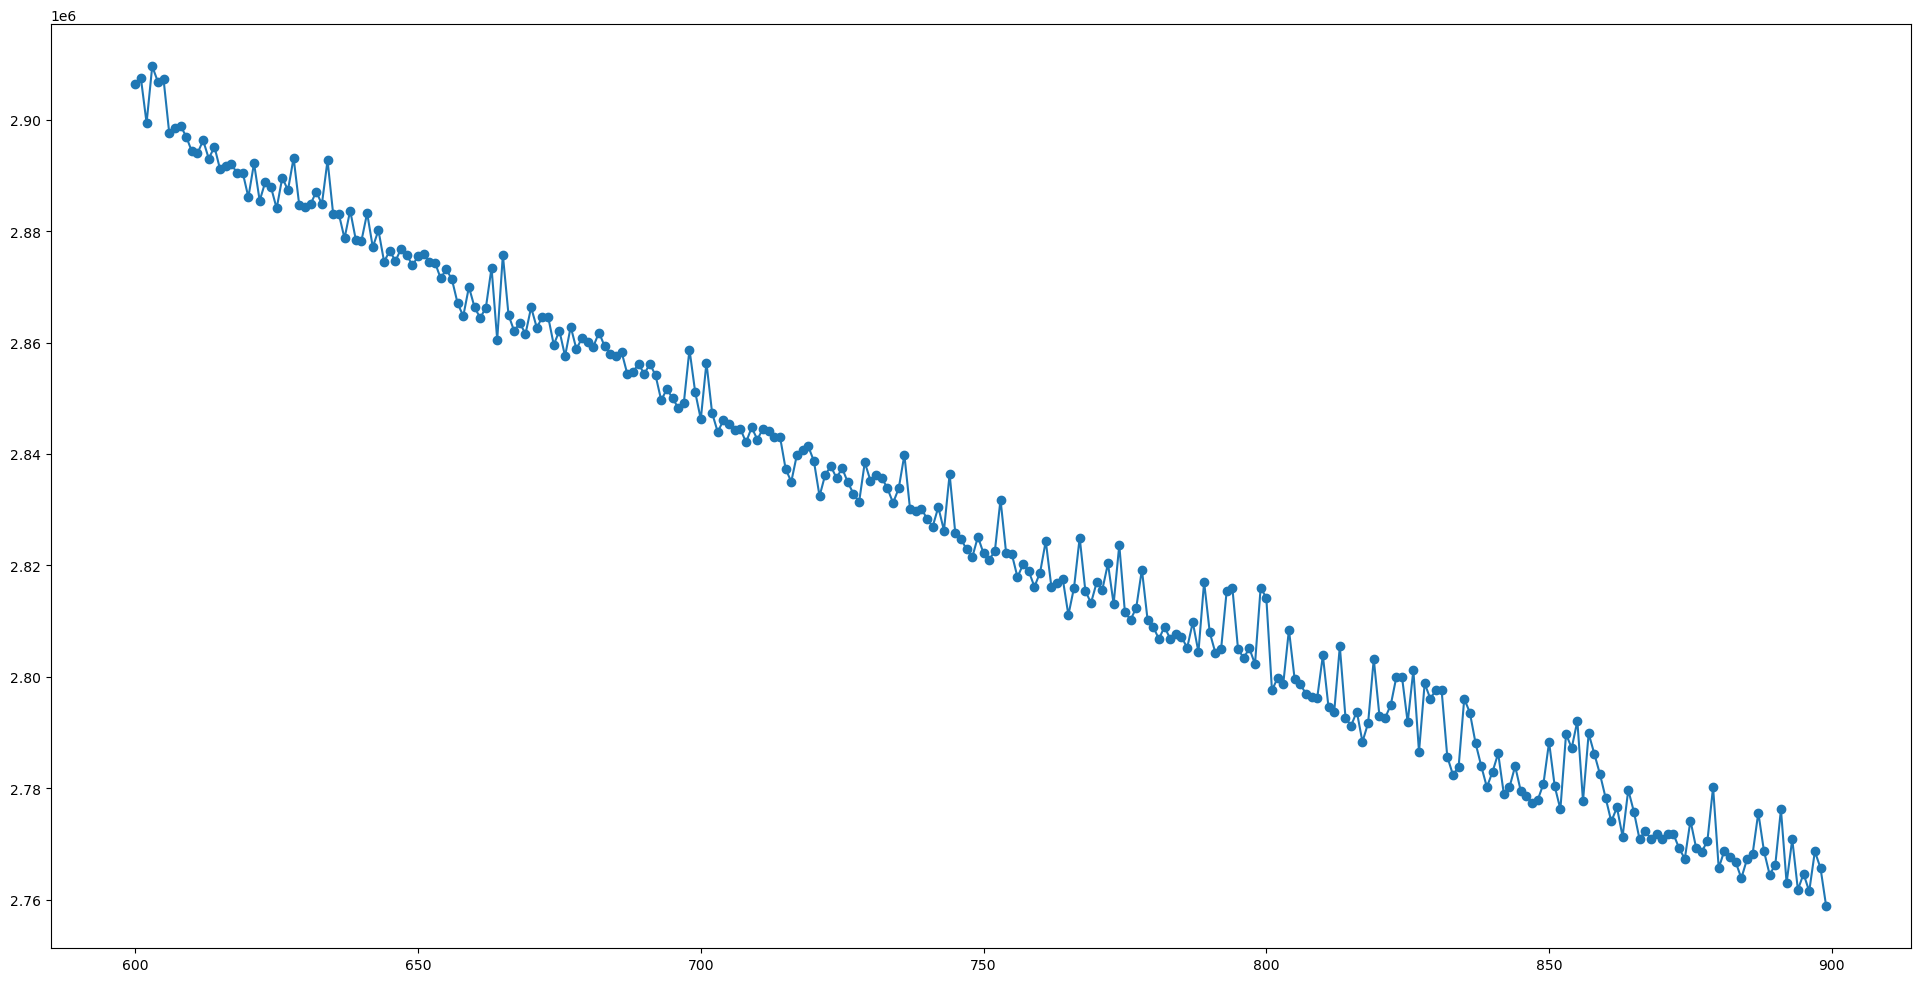

In [18]:
inertia = [
    n_samples * np.exp((aic - 2 * k * n_features) / n_samples)
    for k, aic in zip(k_values, aic_scores)
]
plt.figure(figsize=(24, 12))
plt.plot(k_values, inertia, 'o-')


100%|██████████| 100/100 [28:10<00:00, 16.91s/it]

Numero ottimale di cluster (knee): 604


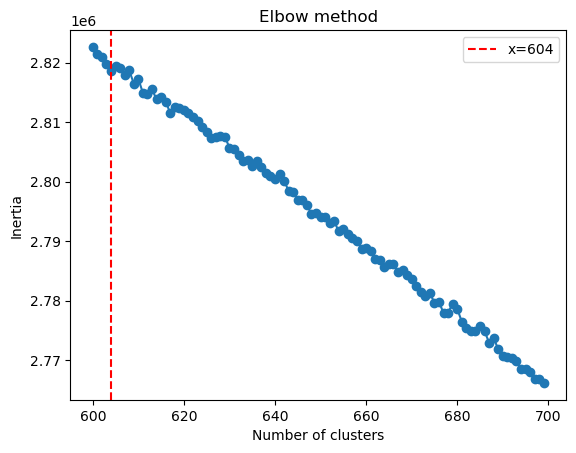

In [ ]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

X = states

inertias = []
ks = range(600,700)
for k in tqdm(ks):
    km = KMeans(n_clusters=k, random_state=1997)
    km.fit(X)
    inertias.append(km.inertia_)

knee = KneeLocator(
    ks,
    inertias,
    curve="convex",
    direction="decreasing"
)

print("Numero ottimale di cluster (knee):", knee.knee)
plt.plot(ks, inertias, 'o-')
plt.axvline(x=knee.knee, color='red', linestyle='--', label=f'x={knee.knee}')
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method")
plt.legend()
plt.show()

k=600 mean_inertia=2.904e+06 std=1.668e+03
k=610 mean_inertia=2.895e+06 std=1.559e+03
k=620 mean_inertia=2.889e+06 std=3.057e+03
k=630 mean_inertia=2.885e+06 std=3.569e+03
k=640 mean_inertia=2.880e+06 std=3.379e+03
k=650 mean_inertia=2.875e+06 std=2.490e+03
k=660 mean_inertia=2.869e+06 std=2.204e+03
k=670 mean_inertia=2.866e+06 std=8.405e+02
k=680 mean_inertia=2.859e+06 std=1.408e+03
k=690 mean_inertia=2.854e+06 std=6.432e+02
k=700 mean_inertia=2.849e+06 std=2.110e+03
k=710 mean_inertia=2.844e+06 std=1.135e+03
k=720 mean_inertia=2.837e+06 std=1.495e+03
k=730 mean_inertia=2.833e+06 std=1.660e+03
k=740 mean_inertia=2.829e+06 std=6.056e+02
k=750 mean_inertia=2.825e+06 std=2.108e+03
k=760 mean_inertia=2.819e+06 std=2.617e+03
k=770 mean_inertia=2.816e+06 std=1.404e+03
k=780 mean_inertia=2.809e+06 std=1.024e+03
k=790 mean_inertia=2.805e+06 std=2.443e+03
k=800 mean_inertia=2.806e+06 std=5.723e+03
Knee (kneed) trovato: 770
k=600 silhouette(sample)=-0.0078
k=610 silhouette(sample)=-0.0046
k=620

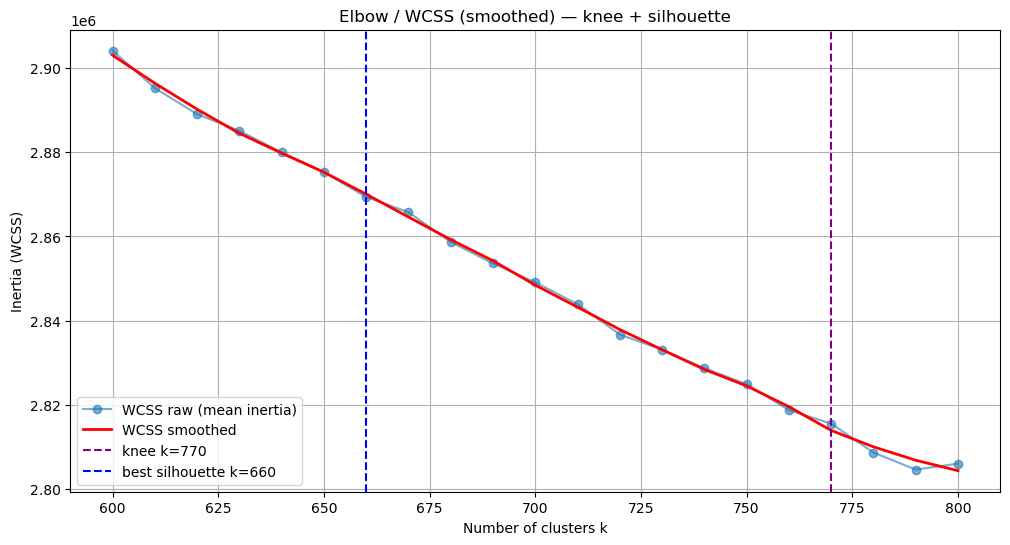

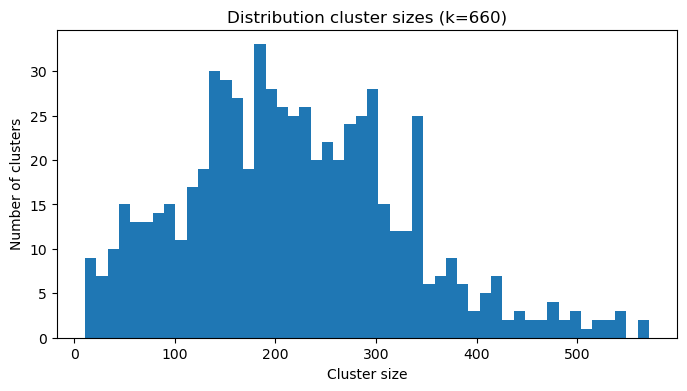

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.utils import resample

# === CONFIGURAZIONE ===
X = states  # tua matrice (n_samples, n_features) già preprocessata (scaling etc.)
# es: X = df.select_dtypes([np.number]).values; scaler.fit_transform(X)
n_samples, n_features = X.shape

k_min, k_max, k_step = 600, 800, 10   # range che vuoi esplorare (personalizza)
k_values = list(range(k_min, k_max+1, k_step))

batch_size = 2048       # aumentare per ridurre rumore su Windows+MKL e in generale
max_iter = 200
n_init = 3              # più init -> più stabile l'inertia media
sample_for_sil = 5000   # silhouette calcolata su campione
smooth_window = 7       # larghezza finestra (deve essere dispari)
ari_runs = 3            # numero di run per valutare stabilità ARI

# === FUNZIONI UTILITARIE ===
def moving_average(y, window):
    if window <= 1:
        return y
    box = np.ones(window) / window
    y_smooth = np.convolve(y, box, mode='same')
    # per bordi: riempire con valori originali o primo/ultimo valido
    return y_smooth

def compute_inertia_for_k(X, k):
    # esegui n_init volte e prendi la media e lo std dell'inertia
    inertias = []
    for seed in range(n_init):
        mbk = MiniBatchKMeans(n_clusters=k, init='k-means++',
                              batch_size=batch_size, max_iter=max_iter,
                              random_state=42 + seed, n_init=1)
        mbk.fit(X)
        inertias.append(mbk.inertia_)
    return np.mean(inertias), np.std(inertias)

# === 1) Calcola inertia per tutto il range (ci mette un po', ma usa MiniBatch) ===
inertias_mean = []
inertias_std = []

for k in k_values:
    mean_in, std_in = compute_inertia_for_k(X, k)
    inertias_mean.append(mean_in)
    inertias_std.append(std_in)
    print(f"k={k} mean_inertia={mean_in:.3e} std={std_in:.3e}")

inertias_mean = np.array(inertias_mean)
inertias_std = np.array(inertias_std)

# === 2) Smoothing della curva WCSS ===
inertia_smooth = moving_average(inertias_mean, smooth_window)

# (opzionale: usa Savitzky-Golay se scipy è disponibile per conservare picchi)
try:
    from scipy.signal import savgol_filter
    if smooth_window % 2 == 0:
        smooth_window += 1
    inertia_savgol = savgol_filter(inertias_mean, window_length=smooth_window, polyorder=2)
    inertia_used = inertia_savgol
except Exception:
    inertia_used = inertia_smooth

# === 3) Trova knee con kneed sulla curva smussata ===
kl = KneeLocator(k_values, inertia_used, curve='convex', direction='decreasing')
k_knee = kl.knee
print("Knee (kneed) trovato:", k_knee)

# === 4) Calcola silhouette su campione per ogni k (su sample per velocità) ===
# nota: silhouette è calcolato in memoria, quindi prendi max sample_for_sil
sample_size = min(sample_for_sil, n_samples)
rng = np.random.RandomState(42)
sample_idx = rng.choice(n_samples, sample_size, replace=False)
X_sample = X[sample_idx]

sil_scores = []
for k in k_values:
    mbk = MiniBatchKMeans(n_clusters=k, init='k-means++', batch_size=batch_size,
                          max_iter=max_iter, random_state=42)
    labels = mbk.fit_predict(X)   # fit su tutto -> etichette, costoso ma ok con MiniBatch
    labels_sample = labels[sample_idx]
    sil = silhouette_score(X_sample, labels_sample)
    sil_scores.append(sil)
    print(f"k={k} silhouette(sample)={sil:.4f}")

best_k_sil = k_values[int(np.argmax(sil_scores))]
print("k con silhouette massima (su sample):", best_k_sil)

# === 5) Stabilita' dei cluster: ARI fra più run per alcuni k selezionati ===
# scegli alcuni k di interesse: knee, best silhouette, e un paio intorno
candidates = sorted(set([k_knee, best_k_sil,
                         k_values[max(0, k_values.index(best_k_sil)-1)],
                         k_values[min(len(k_values)-1, k_values.index(best_k_sil)+1)]]))
candidates = [c for c in candidates if c is not None]
ari_summary = {}

for k in candidates:
    labels_runs = []
    for run in range(ari_runs):
        mbk = MiniBatchKMeans(n_clusters=k, init='k-means++',
                              batch_size=batch_size, max_iter=max_iter,
                              random_state=100 + run)
        labels = mbk.fit_predict(X)
        labels_runs.append(labels[sample_idx])  # confrontiamo sullo stesso sample
    # calcola ARI medio pairwise
    pairwise = []
    for i in range(len(labels_runs)):
        for j in range(i+1, len(labels_runs)):
            pairwise.append(adjusted_rand_score(labels_runs[i], labels_runs[j]))
    ari_summary[k] = np.mean(pairwise) if pairwise else 1.0
    print(f"k={k} ARI medio tra run: {ari_summary[k]:.4f}")

# === 6) Esegui modello finale per k scelto (es. scelgo k_knee o best_k_sil secondo priorita') ===
# qui scegli la regola che preferisci; per esempio preferisco silhouette ma verifico ARI
chosen_k = best_k_sil  # oppure k_knee, o logica ibrida: se ARI troppo bassa, prefer knee
print("Chosen k:", chosen_k)

final_mbk = MiniBatchKMeans(n_clusters=chosen_k, init='k-means++',
                            batch_size=batch_size, max_iter=500, random_state=42)
final_labels = final_mbk.fit_predict(X)
cluster_sizes = np.bincount(final_labels)
print("Cluster sizes (min,max,median):", cluster_sizes.min(), cluster_sizes.max(), np.median(cluster_sizes))

# Merge o rimuovi cluster troppo piccoli (opzionale)
min_cluster_size = max(1, int(0.001 * n_samples))  # es. 0.1% dei dati come soglia
small_clusters = np.where(cluster_sizes < min_cluster_size)[0]
if len(small_clusters) > 0:
    print("Cluster troppo piccoli:", small_clusters, "— considera merging/postprocessing")

# === 7) Plot riassuntivo ===
plt.figure(figsize=(12,6))
plt.plot(k_values, inertias_mean, marker='o', alpha=0.6, label='WCSS raw (mean inertia)')
plt.plot(k_values, inertia_used, color='red', linewidth=2, label='WCSS smoothed')
if k_knee is not None:
    plt.axvline(k_knee, color='purple', linestyle='--', label=f'knee k={k_knee}')
plt.axvline(best_k_sil, color='blue', linestyle='--', label=f'best silhouette k={best_k_sil}')
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow / WCSS (smoothed) — knee + silhouette")
plt.legend()
plt.grid(True)
plt.show()

# cluster size histogram
plt.figure(figsize=(8,4))
plt.hist(cluster_sizes, bins=50)
plt.xlabel("Cluster size")
plt.ylabel("Number of clusters")
plt.title(f"Distribution cluster sizes (k={chosen_k})")
plt.show()
